<a href="https://colab.research.google.com/github/gokul2557/ML/blob/main/EXP2(Logistical%20Regression).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
url = "https://stats.idre.ucla.edu/stat/stata/dae/binary.dta"

data = pd.read_stata(url)

print(data.shape)
data.head()

(400, 4)


,admit,gre,gpa,rank
0,0.0,380.0,3.61,3.0
1,1.0,660.0,3.67,3.0
2,1.0,800.0,4.00,1.0
3,1.0,640.0,3.19,4.0
4,0.0,520.0,2.93,4.0


In [3]:
data.isnull().sum()

,0
admit,0
gre,0
gpa,0
rank,0


In [4]:
feature_cols = ['gre', 'gpa', 'rank']

x = data[feature_cols]
y = data['admit']

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=5
)

display(
    x_train.shape,
    y_train.shape,
    x_test.shape,
    y_test.shape
)

(320, 3)

(320,)

(80, 3)

(80,)

In [6]:
model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [7]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)

print("Confusion Matrix :")
print(conf_mat)

accuracy_score = metrics.accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy_score)

print(
    "Accuracy in Percentage :",
    int(accuracy_score * 100),
    "%"
)

Confusion Matrix :
[[50  4]
 [23  3]]
Accuracy Score : 0.6625
Accuracy in Percentage : 66 %


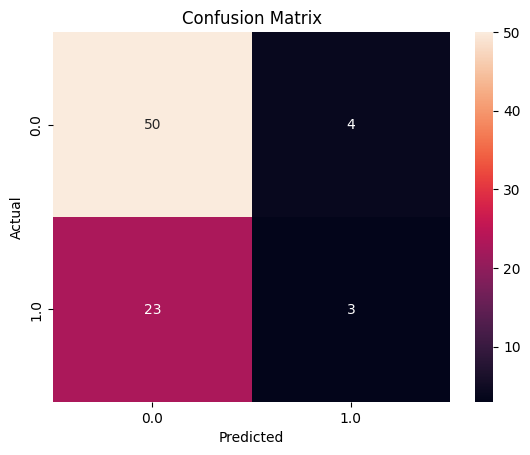

In [8]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)

sns.heatmap(
    conf_mat,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")
plt.show()

In [9]:
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[0]
})

coefficients

,Feature,Coefficient
0,gre,0.002717
1,gpa,0.764137
2,rank,-0.617363


In [10]:
new_student = pd.DataFrame({
    'gre': [700],
    'gpa': [3.8],
    'rank': [1]
})

prediction = model.predict(new_student)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Student is likely to be ADMITTED")
else:
    print("Student is likely to be NOT ADMITTED")

Prediction: 1.0
Student is likely to be ADMITTED


In [11]:
probability = model.predict_proba(new_student)

print("Probability of NOT ADMIT:", probability[0][0])
print("Probability of ADMIT:", probability[0][1])

Probability of NOT ADMIT: 0.34536120187658614
Probability of ADMIT: 0.6546387981234139
